# Laboratorio 06 - Lab03: Regresión Polinómica con PyTorch
## Predicción de la Temperatura Crítica de Superconductores
**Estudiante:** Karen Villarpando Olmedo

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

# 2. Cargar el Dataset

In [4]:
ruta = 'train.csv'

df = pd.read_csv(ruta)

print("Dataset cargado correctamente")
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

df.head()

Dataset cargado correctamente
Filas: 21263
Columnas: 82


,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
0,4,88.944468,57.862692,66.361592,36.116612,1.181795,1.062396,122.90607,31.794921,51.968828,...,2.257143,2.213364,2.219783,1.368922,1.066221,1,1.085714,0.433013,0.437059,29.0
1,5,92.729214,58.518416,73.132787,36.396602,1.449309,1.057755,122.90607,36.161939,47.094633,...,2.257143,1.888175,2.210679,1.557113,1.047221,2,1.128571,0.632456,0.468606,26.0
2,4,88.944468,57.885242,66.361592,36.122509,1.181795,0.975980,122.90607,35.741099,51.968828,...,2.271429,2.213364,2.232679,1.368922,1.029175,1,1.114286,0.433013,0.444697,19.0
3,4,88.944468,57.873967,66.361592,36.119560,1.181795,1.022291,122.90607,33.768010,51.968828,...,2.264286,2.213364,2.226222,1.368922,1.048834,1,1.100000,0.433013,0.440952,22.0
4,4,88.944468,57.840143,66.361592,36.110716,1.181795,1.129224,122.90607,27.848743,51.968828,...,2.242857,2.213364,2.206963,1.368922,1.096052,1,1.057143,0.433013,0.428809,23.0


# 3. Exploración y selección de características

In [5]:
# Exploración y selección de características

print("Valores nulos totales:", df.isnull().sum().sum())

# Correlación de todas las variables con critical_temp
correlaciones = (
    df.corr(numeric_only=True)['critical_temp']
    .drop('critical_temp')
)

# Ordenar por correlación absoluta
correlaciones = correlaciones.reindex(
    correlaciones.abs().sort_values(ascending=False).index
)

print("\n5 características con mayor correlación:")
print(correlaciones.head(5))

# Seleccionar las 2 mejores
caracteristicas = correlaciones.head(2).index.tolist()

print("\nCaracterísticas seleccionadas:")
print(caracteristicas)

Valores nulos totales: 0

5 características con mayor correlación:
wtd_std_ThermalConductivity    0.721271
range_ThermalConductivity      0.687654
range_atomic_radius            0.653759
std_ThermalConductivity        0.653632
wtd_mean_Valence              -0.632401
Name: critical_temp, dtype: float64

Características seleccionadas:
['wtd_std_ThermalConductivity', 'range_ThermalConductivity']


# 4. Preparar X, y y las características polinómicas

In [6]:
# Variables de entrada
X = df[caracteristicas].values.astype(np.float32)

# Variable objetivo
y = df['critical_temp'].values.astype(np.float32)

# Crear características polinómicas
x1 = X[:, 0]
x2 = X[:, 1]

X_poly = np.column_stack([
    x1,
    x2,
    x1**2,
    x1 * x2,
    x2**2
]).astype(np.float32)

print("Dimensión X original:", X.shape)
print("Dimensión X polinómica:", X_poly.shape)
print("Dimensión y:", y.shape)

print("\nTérminos polinómicos:")
print("x1, x2, x1², x1*x2, x2²")

Dimensión X original: (21263, 2)
Dimensión X polinómica: (21263, 5)
Dimensión y: (21263,)

Términos polinómicos:
x1, x2, x1², x1*x2, x2²


# 5. División de entrenamiento y prueba

In [7]:
# División aleatoria 80% entrenamiento - 20% prueba

np.random.seed(42)

indices = np.random.permutation(len(y))
limite = int(0.8 * len(y))

indices_train = indices[:limite]
indices_test = indices[limite:]

X_train = X_poly[indices_train]
X_test = X_poly[indices_test]

y_train = y[indices_train]
y_test = y[indices_test]

print("Datos de entrenamiento:", len(y_train))
print("Datos de prueba:", len(y_test))

print("\nDimensión X_train:", X_train.shape)
print("Dimensión X_test:", X_test.shape)

Datos de entrenamiento: 17010
Datos de prueba: 4253

Dimensión X_train: (17010, 5)
Dimensión X_test: (4253, 5)


# 6. Normalización

In [8]:
# Normalización usando solo datos de entrenamiento

mu = X_train.mean(axis=0)
sigma = X_train.std(axis=0)

# Evitar división entre cero
sigma[sigma == 0] = 1

X_train_norm = (X_train - mu) / sigma
X_test_norm = (X_test - mu) / sigma

print("Dimensión X_train normalizado:", X_train_norm.shape)
print("Dimensión X_test normalizado:", X_test_norm.shape)

print("\nMedia aproximada del entrenamiento:")
print(X_train_norm.mean(axis=0))

print("\nDesviación aproximada:")
print(X_train_norm.std(axis=0))

Dimensión X_train normalizado: (17010, 5)
Dimensión X_test normalizado: (4253, 5)

Media aproximada del entrenamiento:
[-7.0748715e-06 -8.2124439e-05 -3.3637939e-06 -1.1959544e-06
 -8.4352228e-05]

Desviación aproximada:
[0.9999985  0.99998903 0.9999995  1.0000025  0.99990505]


# 7. Dataset y DataLoader

In [9]:
class SuperconductoresDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).view(-1, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# Crear datasets
train_dataset = SuperconductoresDataset(X_train_norm, y_train)
test_dataset = SuperconductoresDataset(X_test_norm, y_test)

# Crear DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

print("Datos de entrenamiento:", len(train_dataset))
print("Datos de prueba:", len(test_dataset))
print("Lotes de entrenamiento:", len(train_loader))
print("Lotes de prueba:", len(test_loader))

Datos de entrenamiento: 17010
Datos de prueba: 4253
Lotes de entrenamiento: 266
Lotes de prueba: 67


# 8. Modelo de red neuronal con PyTorch

In [10]:
# Modelo de Red Neuronal

model = nn.Sequential(
    nn.Linear(5, 16),
    nn.ReLU(),
    nn.Linear(16, 1)
)

print(model)

Sequential(
  (0): Linear(in_features=5, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=1, bias=True)
)


# 9. Función de pérdida y optimizador

In [12]:
# Función de pérdida
criterion = nn.MSELoss()

# Optimizador
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Función de pérdida:", criterion)
print("Optimizador:", optimizer.__class__.__name__)

Función de pérdida: MSELoss()
Optimizador: Adam


# 10. Entrenamiento de la red neuronal

In [13]:
# Parámetros de entrenamiento
epochs = 150
loss_history = []

for epoch in range(1, epochs + 1):

    model.train()
    loss_epoch = 0

    for X_batch, y_batch in train_loader:

        # Predicción
        y_pred = model(X_batch)

        # Calcular pérdida
        loss = criterion(y_pred, y_batch)

        # Reiniciar gradientes
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Actualizar pesos
        optimizer.step()

        loss_epoch += loss.item()

    # Pérdida promedio de la época
    loss_promedio = loss_epoch / len(train_loader)
    loss_history.append(loss_promedio)

    if epoch % 10 == 0:
        print(f"Epoch {epoch}/{epochs} - Loss: {loss_promedio:.4f}")

Epoch 10/150 - Loss: 525.6217
Epoch 20/150 - Loss: 522.5303
Epoch 30/150 - Loss: 518.5703
Epoch 40/150 - Loss: 514.5899
Epoch 50/150 - Loss: 510.9531
Epoch 60/150 - Loss: 508.4794
Epoch 70/150 - Loss: 506.6600
Epoch 80/150 - Loss: 505.5243
Epoch 90/150 - Loss: 504.7775
Epoch 100/150 - Loss: 504.3524
Epoch 110/150 - Loss: 503.9432
Epoch 120/150 - Loss: 503.5754
Epoch 130/150 - Loss: 503.6513
Epoch 140/150 - Loss: 503.4112
Epoch 150/150 - Loss: 503.2316


# 11. Gráfica de la pérdida

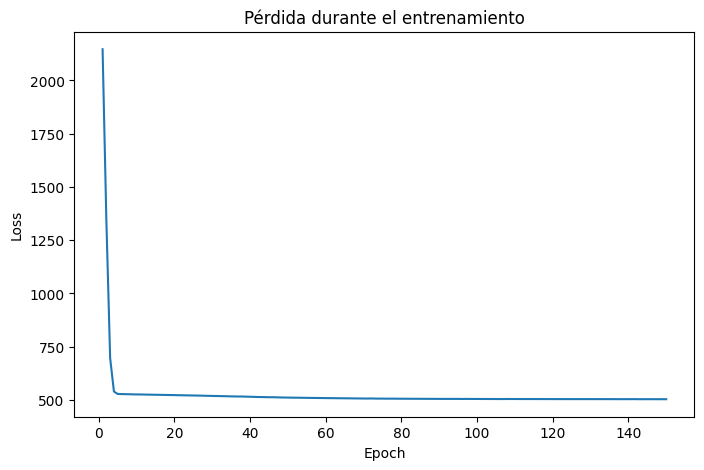

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(range(1, epochs + 1), loss_history)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Pérdida durante el entrenamiento")

plt.show()

# 12. Predicciones sobre datos de prueba

In [15]:
# Predicciones sobre datos de prueba

model.eval()

predicciones = []
reales = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        y_pred = model(X_batch)

        predicciones.extend(
            y_pred.numpy().flatten()
        )

        reales.extend(
            y_batch.numpy().flatten()
        )

print(f"{'Real':>12} {'Predicción':>12}")
print("-" * 26)

for i in range(10):
    print(f"{reales[i]:12.2f} {predicciones[i]:12.2f}")

        Real   Predicción
--------------------------
        3.93        11.10
        6.50        28.72
       82.00        40.81
       13.30        28.70
        1.02        74.64
        6.62        11.33
        4.21         6.09
       67.50        69.03
       54.50        69.29
      110.00        68.32


# 13. Evaluación: MAE, RMSE y R²

In [16]:
# Convertir a arrays de NumPy
reales_np = np.array(reales)
predicciones_np = np.array(predicciones)

# MAE
mae = np.mean(
    np.abs(reales_np - predicciones_np)
)

# RMSE
rmse = np.sqrt(
    np.mean((reales_np - predicciones_np) ** 2)
)

# R²
ss_res = np.sum(
    (reales_np - predicciones_np) ** 2
)

ss_tot = np.sum(
    (reales_np - np.mean(reales_np)) ** 2
)

r2 = 1 - (ss_res / ss_tot)

print("Métricas del modelo")
print("-------------------------")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")

Métricas del modelo
-------------------------
MAE: 16.43
RMSE: 22.62
R²: 0.5704


# 14. Inferencia con datos nuevos

In [17]:
# Valores nuevos para las 2 características originales

nuevo_x1 = df[caracteristicas[0]].median()
nuevo_x2 = df[caracteristicas[1]].median()

print("Nuevo dato:")
print(f"{caracteristicas[0]}: {nuevo_x1:.2f}")
print(f"{caracteristicas[1]}: {nuevo_x2:.2f}")

# Crear términos polinómicos
nuevo_poly = np.array([[
    nuevo_x1,
    nuevo_x2,
    nuevo_x1**2,
    nuevo_x1 * nuevo_x2,
    nuevo_x2**2
]], dtype=np.float32)

# Normalizar con los mismos valores del entrenamiento
nuevo_norm = (nuevo_poly - mu) / sigma

# Convertir a tensor
nuevo_tensor = torch.tensor(
    nuevo_norm,
    dtype=torch.float32
)

# Inferencia
model.eval()

with torch.no_grad():
    prediccion = model(nuevo_tensor)

print(f"\nTemperatura crítica estimada: {prediccion.item():.2f}")

Nuevo dato:
wtd_std_ThermalConductivity: 113.56
range_ThermalConductivity: 399.80

Temperatura crítica estimada: 28.83


# 15. Guardar el modelo

In [18]:
from google.colab import drive
drive.mount('/content/gdrive')

ruta_modelo = '/content/gdrive/MyDrive/modelo_lab03_karen_pytorch.pth'

torch.save(model.state_dict(), ruta_modelo)

print("Modelo guardado correctamente")
print("Ruta:", ruta_modelo)

Mounted at /content/gdrive
Modelo guardado correctamente
Ruta: /content/gdrive/MyDrive/modelo_lab03_karen_pytorch.pth
